<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [4]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [9]:
## Write your code here

df.duplicated().sum()

0

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [13]:
## Write your code here

df['CodingActivities'].isnull().sum()

10971

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [17]:
## Write your code here

# Forward fill missing values in CodingActivities
df["CodingActivities"].fillna(method="ffill", inplace=True)

# Check if any missing values remain
print(f"Missing values in 'CodingActivities' after forward-fill: {df['CodingActivities'].isnull().sum()}")


Missing values in 'CodingActivities' after forward-fill: 0


C:\Users\praka\AppData\Local\Temp\ipykernel_30884\511869731.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CodingActivities"].fillna(method="ffill", inplace=True)
C:\Users\praka\AppData\Local\Temp\ipykernel_30884\511869731.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["CodingActivities"].fillna(method="ffill", inplace=True)


In [19]:
df["CodingActivities"]

0                                                    Hobby
1        Hobby;Contribute to open-source projects;Other...
2        Hobby;Contribute to open-source projects;Other...
3        Hobby;Contribute to open-source projects;Other...
4        Hobby;Contribute to open-source projects;Other...
                               ...                        
65432                        Hobby;School or academic work
65433             Hobby;Contribute to open-source projects
65434                                                Hobby
65435    Hobby;Contribute to open-source projects;Profe...
65436    Hobby;Contribute to open-source projects;Profe...
Name: CodingActivities, Length: 65437, dtype: object

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [37]:
## Write your code here

pd.set_option('display.float_format', '{:,.2f}'.format)

if "ConvertedCompYearly" in df.columns:
    print(df["ConvertedCompYearly"].describe())
    print(f"Missing values: {df['ConvertedCompYearly'].isnull().sum()}")

count       23,435.00
mean        86,155.29
std        186,756.97
min              1.00
25%         32,712.00
50%         65,000.00
75%        107,971.50
max     16,256,603.00
Name: ConvertedCompYearly, dtype: float64
Missing values: 42002


In [35]:
df[df["ConvertedCompYearly"].notnull()]

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
72,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,65.0,100.0,100.0,100.0,50.0,90.0,Too long,Easy,7322.0,10.0
374,375,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Colleague;On the job tr...,Written Tutorials;Stack Overflow;Written-based...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,30074.0,NaN
379,380,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Social Media;Wri...,...,0.0,0.0,0.0,0.0,0.0,0.0,Too long,Difficult,91295.0,10.0
385,386,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;On the job training;Oth...,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,53703.0,NaN
389,390,I am a developer by profession,25-34 years old,"Employed, full-time;Student, part-time",Remote,Apples,Hobby;School or academic work,Some college/university study without earning ...,Books / Physical media;Colleague;On the job tr...,Written Tutorials;Stack Overflow;Coding sessio...,...,20.0,30.0,5.0,20.0,10.0,5.0,Too long,Easy,110000.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41180,41181,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Written Tutorials;Stac...,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,44640.0,NaN
41184,41185,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Freel...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books,...,20.0,10.0,20.0,15.0,0.0,0.0,Appropriate in length,Easy,170000.0,9.0
41185,41186,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Other (please specify):,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,116844.0,NaN
41186,41187,I am a developer by profession,18-24 years old,"Student, full-time;Employed, part-time","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Books;Written Tutorial...,...,20.0,25.0,15.0,5.0,5.0,0.0,Appropriate in length,Easy,12000.0,3.0


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [49]:
## Write your code here

# Fill missing values with median
median_val = df["ConvertedCompYearly"].median()
df["ConvertedCompYearly"].fillna(median_val, inplace=True)

# Then do Min-Max scaling
min_val = df["ConvertedCompYearly"].min()
max_val = df["ConvertedCompYearly"].max()

df["ConvertedCompYearly_MinMax"] = (df["ConvertedCompYearly"] - min_val) / (max_val - min_val)
print(df[["ConvertedCompYearly", "ConvertedCompYearly_MinMax"]].head())


   ConvertedCompYearly  ConvertedCompYearly_MinMax
0            65,000.00                        0.00
1            65,000.00                        0.00
2            65,000.00                        0.00
3            65,000.00                        0.00
4            65,000.00                        0.00


C:\Users\praka\AppData\Local\Temp\ipykernel_30884\1900083033.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ConvertedCompYearly"].fillna(median_val, inplace=True)


In [41]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Step 1: Fill missing values with median
median_val = df["ConvertedCompYearly"].median()
df["ConvertedCompYearly"].fillna(median_val, inplace=True)

# Step 2: Cap extreme outliers (1st and 99th percentile)
lower = df["ConvertedCompYearly"].quantile(0.01)
upper = df["ConvertedCompYearly"].quantile(0.99)
df["ConvertedCompYearly_Capped"] = df["ConvertedCompYearly"].clip(lower, upper)

# Step 3: Min-Max Scaling
scaler = MinMaxScaler()
df["ConvertedCompYearly_MinMax"] = scaler.fit_transform(df[["ConvertedCompYearly_Capped"]])

# Check results
print(df[["ConvertedCompYearly", "ConvertedCompYearly_Capped", "ConvertedCompYearly_MinMax"]].head())


   ConvertedCompYearly  ConvertedCompYearly_Capped  ConvertedCompYearly_MinMax
0            65,000.00                   65,000.00                        0.26
1            65,000.00                   65,000.00                        0.26
2            65,000.00                   65,000.00                        0.26
3            65,000.00                   65,000.00                        0.26
4            65,000.00                   65,000.00                        0.26


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [53]:
## Write your code here

import pandas as pd

# Step 1: Fill missing values with median (optional, to avoid NaNs)
median_val = df["ConvertedCompYearly"].median()
df["ConvertedCompYearly"].fillna(median_val, inplace=True)

# Step 2: Calculate mean and standard deviation
mean_val = df["ConvertedCompYearly"].mean()
std_val = df["ConvertedCompYearly"].std()

# Step 3: Compute Z-score
df["ConvertedCompYearly_Zscore"] = (df["ConvertedCompYearly"] - mean_val) / std_val

# Check results
print(df[["ConvertedCompYearly", "ConvertedCompYearly_Zscore"]].head())



   ConvertedCompYearly  ConvertedCompYearly_Zscore
0            65,000.00                       -0.07
1            65,000.00                       -0.07
2            65,000.00                       -0.07
3            65,000.00                       -0.07
4            65,000.00                       -0.07


C:\Users\praka\AppData\Local\Temp\ipykernel_30884\2836854674.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ConvertedCompYearly"].fillna(median_val, inplace=True)


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


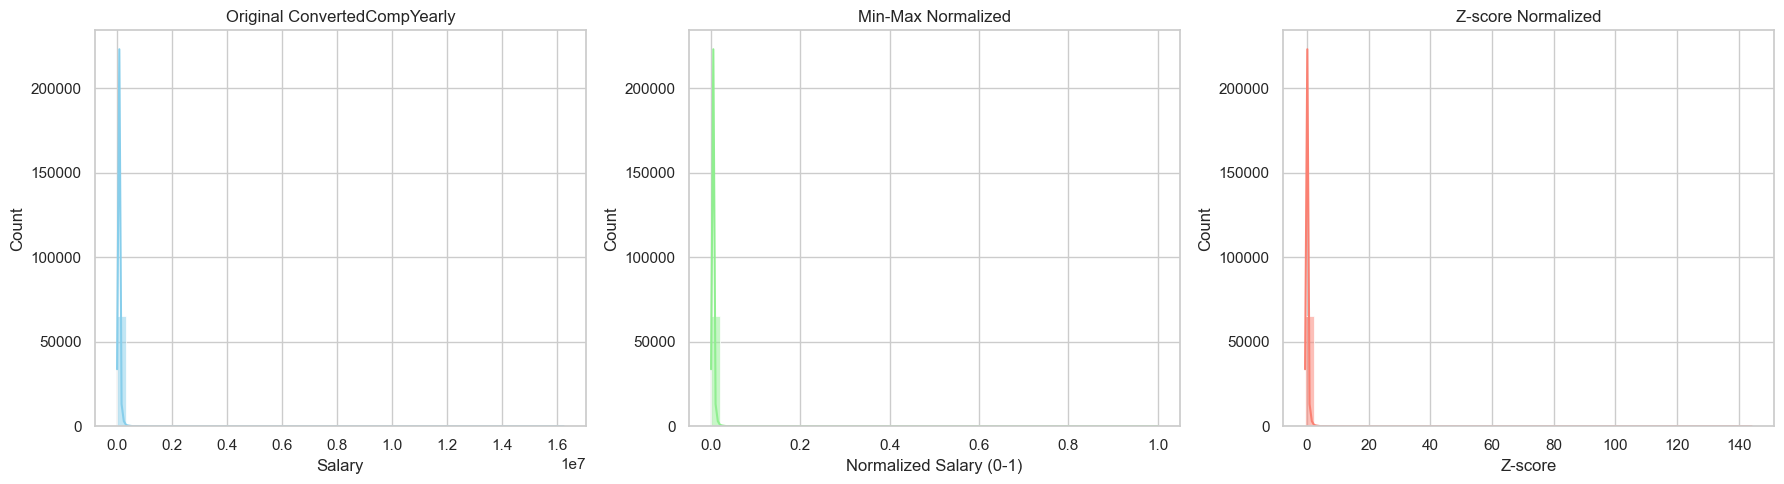

In [55]:
## Write your code here

import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style
sns.set(style="whitegrid")

# Create a figure with 3 subplots side by side
plt.figure(figsize=(18, 5))

# 1. Original data
plt.subplot(1, 3, 1)
sns.histplot(df["ConvertedCompYearly"], bins=50, kde=True, color="skyblue")
plt.title("Original ConvertedCompYearly")
plt.xlabel("Salary")
plt.ylabel("Count")

# 2. Min-Max Normalized data
plt.subplot(1, 3, 2)
sns.histplot(df["ConvertedCompYearly_MinMax"], bins=50, kde=True, color="lightgreen")
plt.title("Min-Max Normalized")
plt.xlabel("Normalized Salary (0-1)")
plt.ylabel("Count")

# 3. Z-score Normalized data
plt.subplot(1, 3, 3)
sns.histplot(df["ConvertedCompYearly_Zscore"], bins=50, kde=True, color="salmon")
plt.title("Z-score Normalized")
plt.xlabel("Z-score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
